In [2]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# Download 5 years of Reliance Industries data
reliance = yf.download("RELIANCE.NS", start="2019-01-01", end="2024-01-01")

print(reliance.head())
print(f"\nShape: {reliance.shape}")

[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open      Volume
Ticker     RELIANCE.NS RELIANCE.NS RELIANCE.NS RELIANCE.NS RELIANCE.NS
Date                                                                  
2019-01-01  498.490570  501.292117  493.643536  500.380512     9746670
2019-01-02  491.998199  501.158692  489.596886  495.600125    15628818
2019-01-03  485.928253  495.644585  484.749845  492.487331    16288287
2019-01-04  488.551910  491.131092  480.747723  487.996071    18516544
2019-01-07  491.264496  497.356669  489.596920  492.265036    12060290

Shape: (1235, 5)


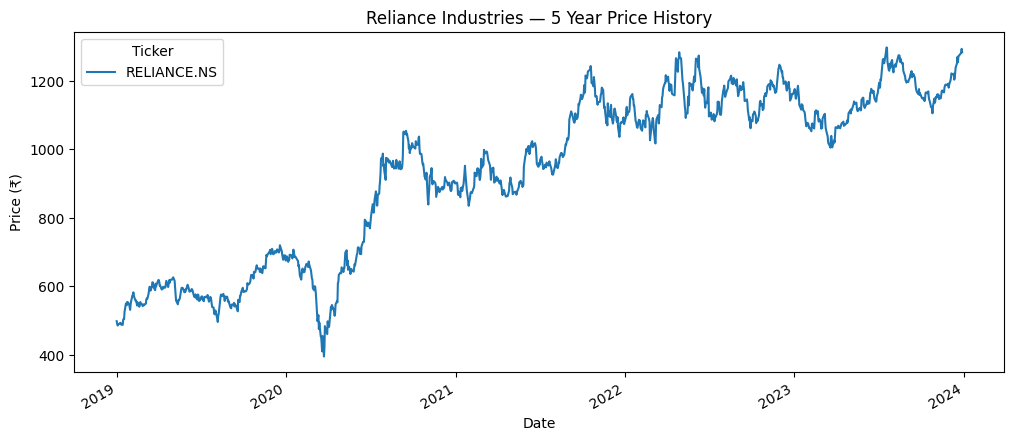

In [3]:
reliance['Close'].plot(figsize=(12, 5), title='Reliance Industries — 5 Year Price History')
plt.xlabel('Date')
plt.ylabel('Price (₹)')
plt.show()

In [4]:
# Calculate daily returns
reliance['Daily_Return'] = reliance['Close'].pct_change() * 100

print(reliance['Daily_Return'].describe())

count    1234.000000
mean        0.094894
std         1.915904
min       -13.153893
25%        -0.915334
50%         0.055764
75%         0.969974
max        14.718052
Name: Daily_Return, dtype: float64


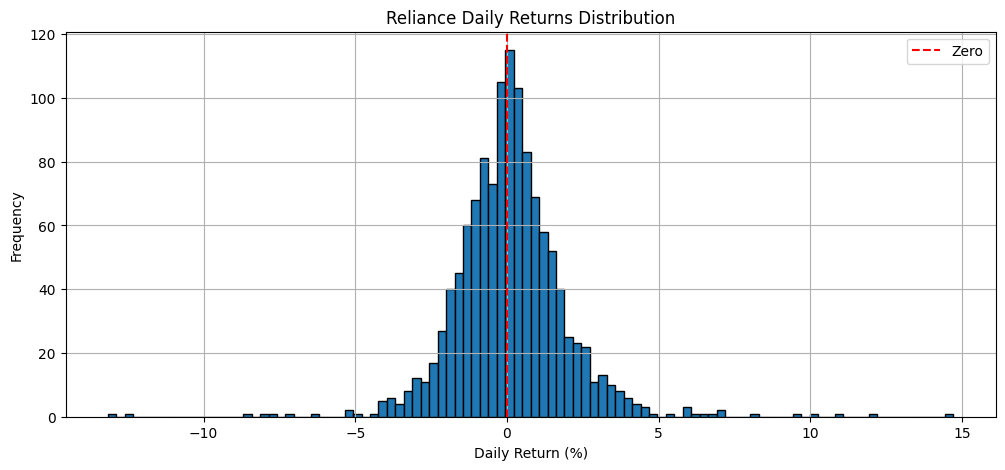

In [5]:
plt.figure(figsize=(12, 5))
reliance['Daily_Return'].hist(bins=100, edgecolor='black')
plt.title('Reliance Daily Returns Distribution')
plt.xlabel('Daily Return (%)')
plt.ylabel('Frequency')
plt.axvline(0, color='red', linestyle='--', label='Zero')
plt.legend()
plt.show()

In [6]:
# What was the best and worst day?
best_day = reliance['Daily_Return'].idxmax()
worst_day = reliance['Daily_Return'].idxmin()

print(f"Best day:  {best_day.date()} → {reliance['Daily_Return'][best_day]:.2f}%")
print(f"Worst day: {worst_day.date()} → {reliance['Daily_Return'][worst_day]:.2f}%")

Best day:  2020-03-25 → 14.72%
Worst day: 2020-03-23 → -13.15%


[*********************100%***********************]  1 of 1 completed


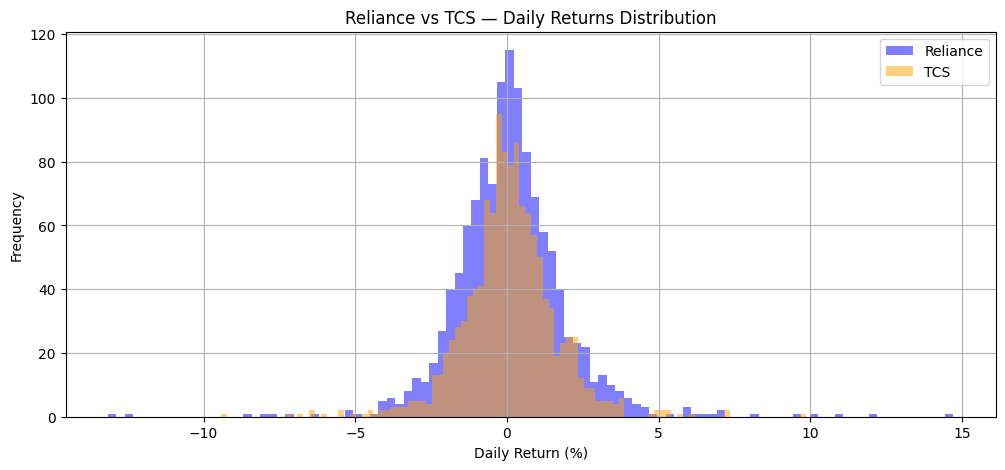

In [7]:
# Download TCS data for the same period
tcs = yf.download("TCS.NS", start="2019-01-01", end="2024-01-01")
tcs['Daily_Return'] = tcs['Close'].pct_change() * 100

# Plot both distributions together
plt.figure(figsize=(12, 5))
reliance['Daily_Return'].hist(bins=100, alpha=0.5, label='Reliance', color='blue')
tcs['Daily_Return'].hist(bins=100, alpha=0.5, label='TCS', color='orange')
plt.title('Reliance vs TCS — Daily Returns Distribution')
plt.xlabel('Daily Return (%)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [8]:
print("Reliance:")
print(f"  Average daily return: {reliance['Daily_Return'].mean():.3f}%")
print(f"  Volatility (std dev): {reliance['Daily_Return'].std():.3f}%")

print("\nTCS:")
print(f"  Average daily return: {tcs['Daily_Return'].mean():.3f}%")
print(f"  Volatility (std dev): {tcs['Daily_Return'].std():.3f}%")

Reliance:
  Average daily return: 0.095%
  Volatility (std dev): 1.916%

TCS:
  Average daily return: 0.077%
  Volatility (std dev): 1.561%


In [10]:
# Sharpe Ratio = Average Return / Volatility
# Higher is better — more return per unit of risk

reliance_sharpe = reliance['Daily_Return'].mean() / reliance['Daily_Return'].std()
tcs_sharpe = tcs['Daily_Return'].mean() / tcs['Daily_Return'].std()

print(f"Reliance Sharpe Ratio: {reliance_sharpe:.5f}")
print(f"TCS Sharpe Ratio:      {tcs_sharpe:.5f}")

if tcs_sharpe > reliance_sharpe:
    print("\nTCS is better on a risk-adjusted basis")
else:
    print("\nReliance is better on a risk-adjusted basis")

Reliance Sharpe Ratio: 0.04953
TCS Sharpe Ratio:      0.04951

Reliance is better on a risk-adjusted basis


₹10,000 invested in Reliance → ₹25737
₹10,000 invested in TCS     → ₹22329


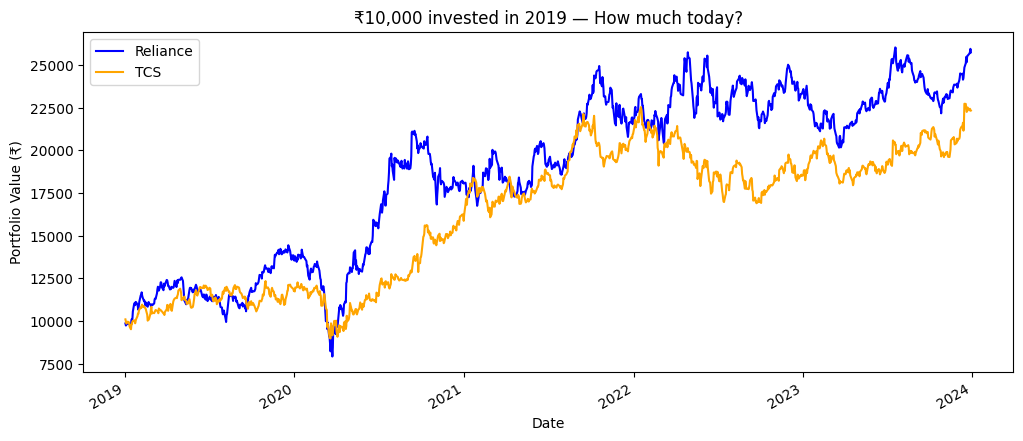

In [11]:
# If you invested ₹10,000 in Reliance and TCS on Jan 1, 2019
# How much would you have on Jan 1, 2024?

investment = 10000

reliance_cumulative = (1 + reliance['Daily_Return']/100).cumprod()
tcs_cumulative = (1 + tcs['Daily_Return']/100).cumprod()

reliance_final = investment * reliance_cumulative.iloc[-1]
tcs_final = investment * tcs_cumulative.iloc[-1]

print(f"₹10,000 invested in Reliance → ₹{reliance_final:.0f}")
print(f"₹10,000 invested in TCS     → ₹{tcs_final:.0f}")

# Plot it
plt.figure(figsize=(12, 5))
(investment * reliance_cumulative).plot(label='Reliance', color='blue')
(investment * tcs_cumulative).plot(label='TCS', color='orange')
plt.title('₹10,000 invested in 2019 — How much today?')
plt.xlabel('Date')
plt.ylabel('Portfolio Value (₹)')
plt.legend()
plt.show()

Correlation between Reliance and TCS: 0.3548


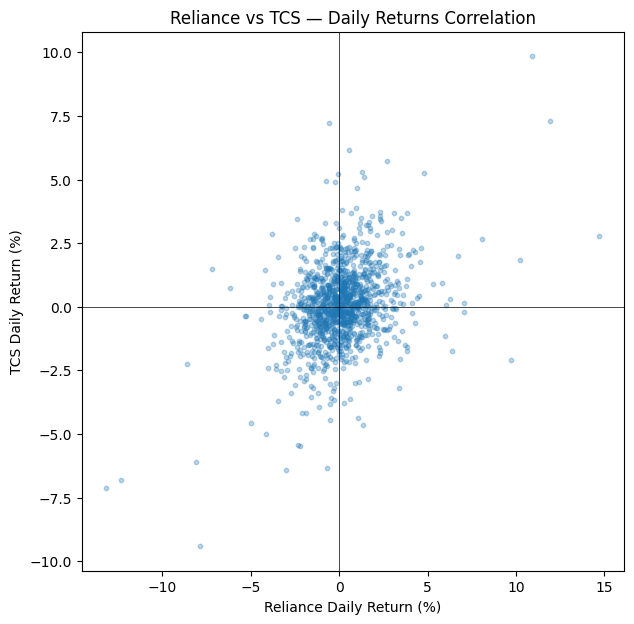

In [12]:
# Correlation — do Reliance and TCS move together?
# 1.0 = perfectly together, 0 = no relationship, -1 = opposite directions

correlation = reliance['Daily_Return'].corr(tcs['Daily_Return'])
print(f"Correlation between Reliance and TCS: {correlation:.4f}")

# Scatter plot
plt.figure(figsize=(7, 7))
plt.scatter(reliance['Daily_Return'], tcs['Daily_Return'], alpha=0.3, s=10)
plt.title('Reliance vs TCS — Daily Returns Correlation')
plt.xlabel('Reliance Daily Return (%)')
plt.ylabel('TCS Daily Return (%)')
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.show()

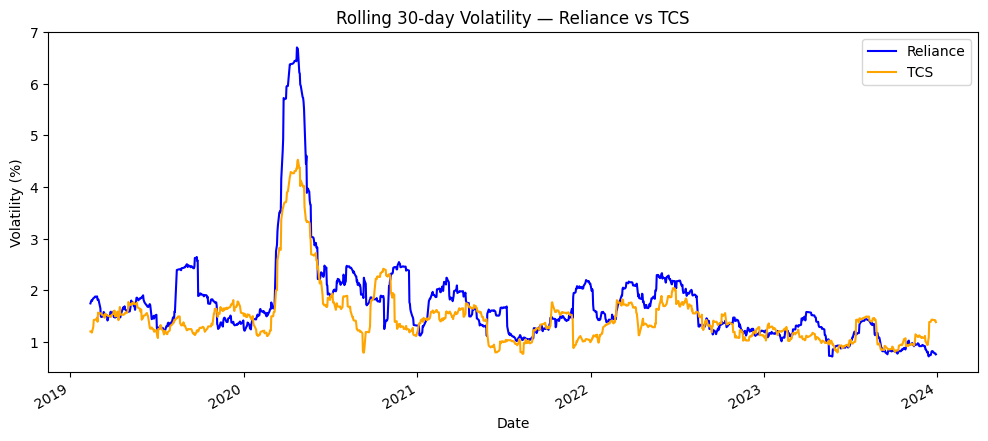

In [13]:
# Rolling volatility — how risk changes over time
# We calculate volatility over a 30-day rolling window

reliance_rolling_vol = reliance['Daily_Return'].rolling(window=30).std()
tcs_rolling_vol = tcs['Daily_Return'].rolling(window=30).std()

plt.figure(figsize=(12, 5))
reliance_rolling_vol.plot(label='Reliance', color='blue')
tcs_rolling_vol.plot(label='TCS', color='orange')
plt.title('Rolling 30-day Volatility — Reliance vs TCS')
plt.xlabel('Date')
plt.ylabel('Volatility (%)')
plt.legend()
plt.show()

In [14]:
# Download Infosys too
infy = yf.download("INFY.NS", start="2019-01-01", end="2024-01-01")
infy['Daily_Return'] = infy['Close'].pct_change() * 100

# Summary table
import pandas as pd

summary = pd.DataFrame({
    'Stock': ['Reliance', 'TCS', 'Infosys'],
    'Avg Daily Return (%)': [
        reliance['Daily_Return'].mean(),
        tcs['Daily_Return'].mean(),
        infy['Daily_Return'].mean()
    ],
    'Volatility (%)': [
        reliance['Daily_Return'].std(),
        tcs['Daily_Return'].std(),
        infy['Daily_Return'].std()
    ],
    'Sharpe Ratio': [
        reliance['Daily_Return'].mean() / reliance['Daily_Return'].std(),
        tcs['Daily_Return'].mean() / tcs['Daily_Return'].std(),
        infy['Daily_Return'].mean() / infy['Daily_Return'].std()
    ],
    'Final Value of ₹10,000': [
        10000 * (1 + reliance['Daily_Return']/100).cumprod().iloc[-1],
        10000 * (1 + tcs['Daily_Return']/100).cumprod().iloc[-1],
        10000 * (1 + infy['Daily_Return']/100).cumprod().iloc[-1]
    ]
})

summary = summary.round(4)
print(summary.to_string(index=False))

[*********************100%***********************]  1 of 1 completed

   Stock  Avg Daily Return (%)  Volatility (%)  Sharpe Ratio  Final Value of ₹10,000
Reliance                0.0949          1.9159        0.0495              25737.2773
     TCS                0.0773          1.5613        0.0495              22329.3803
 Infosys                0.0947          1.8109        0.0523              26246.6535


## Key Takeaways — Day 3

**Best investment:** Infosys was the best investment over 2019-2024.
It had the highest Sharpe ratio meaning best risk-adjusted returns,
and ₹10,000 invested in 2019 grew to ₹26,000+ by 2024 — 
beating both Reliance and TCS.

**Rolling volatility:** Volatility is not constant — it spikes during 
market crises like COVID. For a trader who can predict direction, 
high volatility means more profit opportunity. For a regular investor 
just holding, it's terrifying because swings go both ways.

**Biggest surprise:** Even though TCS had more stable volatility,
Reliance still delivered higher raw returns by taking on more risk.
But on a risk-adjusted basis (Sharpe ratio), Infosys won quietly 
without making as much noise.

## Part 2 — Nifty 50 Multi-Stock Analysis

In [16]:
# Download 5 major Nifty 50 stocks at once
tickers = ['RELIANCE.NS', 'TCS.NS', 'INFY.NS', 'HDFCBANK.NS', 'WIPRO.NS']

data = yf.download(tickers, start="2019-01-01", end="2024-01-01")['Close']

# Calculate daily returns for all at once
returns = data.pct_change() * 100

print(returns.head())
print(f"\nShape: {returns.shape}")

[*********************100%***********************]  5 of 5 completed

Ticker      HDFCBANK.NS   INFY.NS  RELIANCE.NS    TCS.NS  WIPRO.NS
Date                                                              
2019-01-01          NaN       NaN          NaN       NaN       NaN
2019-01-02    -0.912431  0.601442    -1.302406  1.077362 -0.336742
2019-01-03    -0.784594  0.014952    -1.233733 -1.214061 -0.015365
2019-01-04     0.267530 -1.210487     0.539927 -1.215823 -0.322585
2019-01-07     0.151122  1.611066     0.555230  1.121575 -0.061642

Shape: (1235, 5)


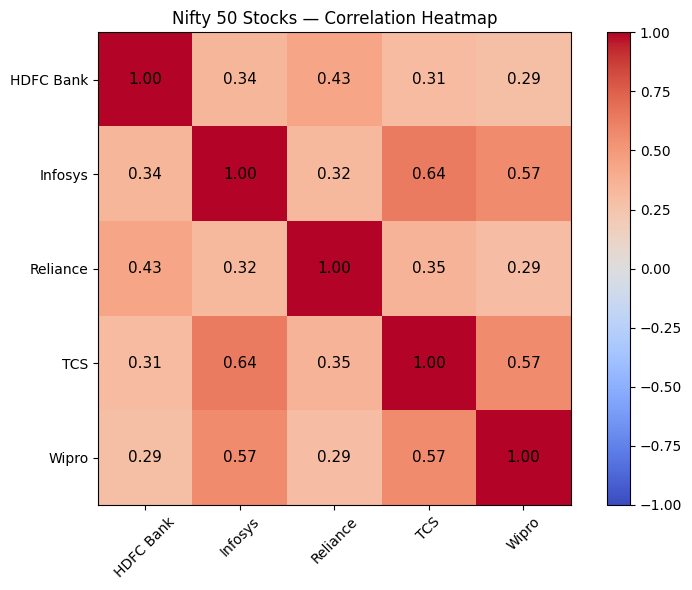

In [17]:
import numpy as np

# Calculate correlation matrix
corr_matrix = returns.corr()

# Plot heatmap manually with matplotlib
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)

# Add colorbar
plt.colorbar(im)

# Add labels
stocks = ['HDFC Bank', 'Infosys', 'Reliance', 'TCS', 'Wipro']
ax.set_xticks(range(len(stocks)))
ax.set_yticks(range(len(stocks)))
ax.set_xticklabels(stocks, rotation=45)
ax.set_yticklabels(stocks)

# Add correlation values inside boxes
for i in range(len(stocks)):
    for j in range(len(stocks)):
        ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                ha='center', va='center', fontsize=11)

plt.title('Nifty 50 Stocks — Correlation Heatmap')
plt.tight_layout()
plt.show()

## Key Takeaway — Correlation Heatmap

A correlation heatmap shows how stocks move relative to each other.
Portfolio managers use it to decide which stocks to combine.

High correlation (near 1.0) is bad for a portfolio — IT stocks like 
TCS, Infosys, and Wipro all have 0.57-0.64 correlation, meaning they 
fall together during bad times. No protection.

Low correlation (near 0) is good — Reliance and Wipro at 0.29 means 
they move mostly independently. When one falls, the other might not.
That's what protects a portfolio during market crashes.

The goal of diversification is to combine low-correlation stocks,
not just different company names.